# Slope Data: Weather Grid Mapping

**Purpose:** Map the CA slope dataset (average and maximum terrain slope)
onto the weather reanalysis grid using a KD-Tree nearest-neighbour lookup.
Cells whose nearest slope pixel is more than 4 km away (ocean / boundary)
are set to 0.

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Inspect** | Load `slope_avg.nc` and `slope_max.nc`; check coverage and missing rates |
| **B. Build Reference Grid** | Extract (lon, lat) pairs from a reference weather NetCDF |
| **C. KD-Tree Match** | Nearest-neighbour match; compute exact geodesic distances |
| **D. Assign & QA** | Apply 4 km distance mask; fill unmatched with 0; visualize |
| **E. Save** | Write matched grid to Parquet |

**Inputs:**
- `Slope_Data/slope_avg.nc` — mean terrain slope (degrees)
- `Slope_Data/slope_max.nc` — maximum terrain slope (degrees)
- `Weather_Data/` — any `.nc` file used to extract the reference (lon, lat) grid

**Output:** `Clean_Data/Slope_Data/lon_lat_pair_weather_match_slope.parquet` — used in `02_05`

## 0. Configuration

Centralized path configuration — **edit this cell only**.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input: slope NetCDF files
SLOPE_AVG_PATH = os.path.join(PROJECT_ROOT, "Slope_Data", "slope_avg.nc")
SLOPE_MAX_PATH = os.path.join(PROJECT_ROOT, "Slope_Data", "slope_max.nc")

# Reference: any weather NetCDF to extract the lon/lat grid
WEATHER_NC_DIR = os.path.join(PROJECT_ROOT, "Weather_Data")

# Distance threshold — grid cells > this many km from nearest slope pixel
# are treated as ocean / out-of-domain and set to 0
MAX_MATCH_KM = 4.0

# Output
OUTPUT_PATH = os.path.join(PROJECT_ROOT, "Clean_Data", "Slope_Data",
                           "lon_lat_pair_weather_match_slope.parquet")

print(f"Slope avg : {SLOPE_AVG_PATH}")
print(f"Slope max : {SLOPE_MAX_PATH}")
print(f"Weather NC: {WEATHER_NC_DIR}")
print(f"Output    : {OUTPUT_PATH}")
for label, path in [("SLOPE_AVG_PATH", SLOPE_AVG_PATH),
                    ("SLOPE_MAX_PATH", SLOPE_MAX_PATH),
                    ("WEATHER_NC_DIR", WEATHER_NC_DIR)]:
    print(f"  [{'OK' if os.path.exists(path) else 'MISSING'}] {label}")

Slope avg : E:\zcao\CA_Wildfire\Slope_Data\slope_avg.nc
Slope max : E:\zcao\CA_Wildfire\Slope_Data\slope_max.nc
Weather NC: E:\zcao\CA_Wildfire\Weather_Data
Output    : E:\zcao\CA_Wildfire\Clean_Data\Slope_Data\lon_lat_pair_weather_match_slope.parquet
  [OK] SLOPE_AVG_PATH
  [OK] SLOPE_MAX_PATH
  [OK] WEATHER_NC_DIR


## 1. Environment Setup

In [2]:
import sys, gc, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from geopy.distance import geodesic
from tqdm import tqdm

gc.collect()
print(f"Python : {sys.version.split('|')[0].strip()}")
print(f"pandas : {pd.__version__}")
print(f"xarray : {xr.__version__}")
print(f"numpy  : {np.__version__}")

Python : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas : 2.2.2
xarray : 2024.7.0
numpy  : 1.24.4


---

# Phase A: Inspect Slope Data

Load both slope NetCDF files, convert to DataFrames, check missing rates,
and visualize coverage before matching.

## 2. Load Slope NetCDF Files

In [3]:
slope_avg_ds = xr.open_dataset(SLOPE_AVG_PATH)
slope_max_ds = xr.open_dataset(SLOPE_MAX_PATH)

print("slope_avg:", dict(slope_avg_ds.dims), list(slope_avg_ds.data_vars))
print("slope_max:", dict(slope_max_ds.dims), list(slope_max_ds.data_vars))

slope_avg = slope_avg_ds.to_dataframe().reset_index()
slope_max = slope_max_ds.to_dataframe().reset_index()

print(f"\nslope_avg shape : {slope_avg.shape}  "
      f"| NA rate: {slope_avg['slope_avg'].isna().mean():.3f}")
print(f"slope_max shape : {slope_max.shape}  "
      f"| NA rate: {slope_max['slope_max'].isna().mean():.3f}")

slope_avg: {'lon': 249, 'lat': 228} ['slope_avg']
slope_max: {'lon': 249, 'lat': 228} ['slope_max']

slope_avg shape : (56772, 3)  | NA rate: 0.566
slope_max shape : (56772, 3)  | NA rate: 0.566


## 3. Merge & Inspect Slope Dataset

In [4]:
# Fill NA with 0 before merging (NAs are flat/ocean areas)
slope_avg['slope_avg'] = slope_avg['slope_avg'].fillna(0)
slope_max['slope_max'] = slope_max['slope_max'].fillna(0)

slope_data = slope_avg.merge(slope_max, on=['lon','lat'], how='inner')
print(f"Merged slope shape : {slope_data.shape}")
print(f"\nslope_avg stats:\n{slope_data['slope_avg'].describe().to_string()}")
print(f"\nslope_max stats:\n{slope_data['slope_max'].describe().to_string()}")

Merged slope shape : (56772, 4)

slope_avg stats:
count    56772.000000
mean         3.731785
std          6.225595
min          0.000000
25%          0.000000
50%          0.000000
75%          5.751600
max         35.430801

slope_max stats:
count    56772.000000
mean        10.586539
std         15.136609
min          0.000000
25%          0.000000
50%          0.000000
75%         24.000000
max         71.000000


## 4. Visualize Raw Slope Coverage

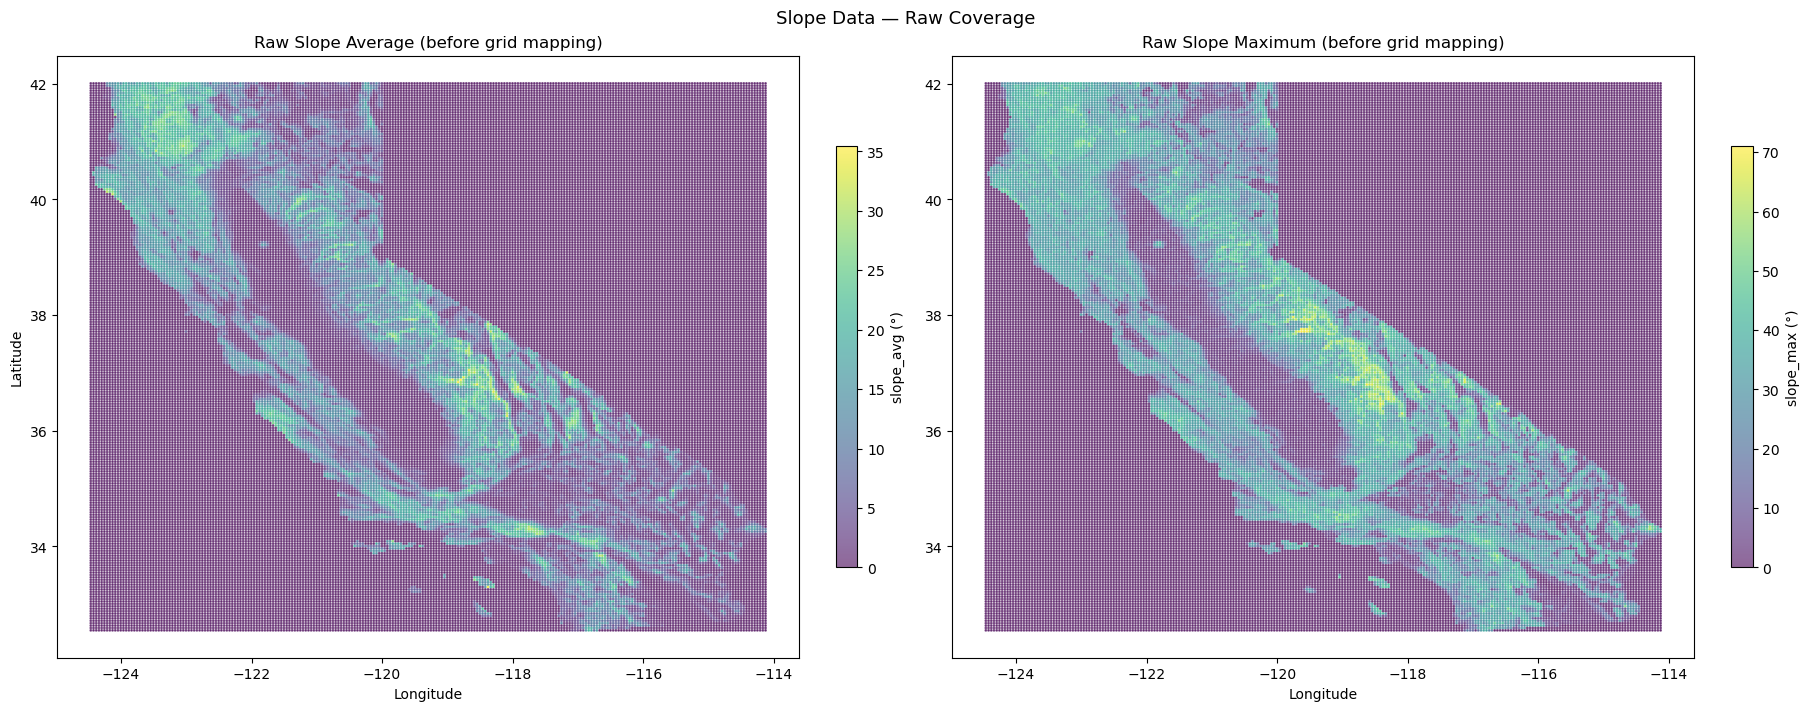

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

sc1 = axes[0].scatter(slope_data['lon'], slope_data['lat'],
                      c=slope_data['slope_avg'], cmap='viridis', s=1, alpha=0.6)
axes[0].set_title('Raw Slope Average (before grid mapping)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
fig.colorbar(sc1, ax=axes[0], label='slope_avg (°)', shrink=0.7)

sc2 = axes[1].scatter(slope_data['lon'], slope_data['lat'],
                      c=slope_data['slope_max'], cmap='viridis', s=1, alpha=0.6)
axes[1].set_title('Raw Slope Maximum (before grid mapping)')
axes[1].set_xlabel('Longitude')
fig.colorbar(sc2, ax=axes[1], label='slope_max (°)', shrink=0.7)

plt.suptitle('Slope Data — Raw Coverage', fontsize=13)
plt.show()

---

# Phase B: Build Reference Weather Grid

Extract the (lon, lat) Cartesian grid from any weather NetCDF file.
This defines the spatial resolution for the slope mapping.

## 5. Extract Weather Grid from NetCDF

In [6]:
nc_files = sorted([f for f in os.listdir(WEATHER_NC_DIR) if f.endswith('.nc')])
assert len(nc_files) > 0, f"No .nc files found in {WEATHER_NC_DIR}"
print(f"Reference file: {nc_files[0]}")

reference_ds = xr.open_dataset(os.path.join(WEATHER_NC_DIR, nc_files[0]))
print(f"Dimensions : {dict(reference_ds.dims)}")

lon = reference_ds.coords['lon'].values
lat = reference_ds.coords['lat'].values

# Cartesian product of all lon × lat
lon_grid, lat_grid = np.meshgrid(lon, lat)
reference_grid = pd.DataFrame({
    'lon': lon_grid.ravel(),
    'lat': lat_grid.ravel(),
})
print(f"Reference grid cells: {len(reference_grid):,}")

Reference file: Palmer_Drought_Severity_Index.2001.2023.CA.nc
Dimensions : {'day': 1679, 'lon': 259, 'lat': 240}
Reference grid cells: 62,160


---

# Phase C: KD-Tree Nearest-Neighbour Match

Build a KD-Tree on the slope coordinates and find the nearest slope pixel
for every weather grid cell. Then compute exact geodesic distances (km).
Cells more than `MAX_MATCH_KM` away are treated as ocean / out-of-domain.

## 6. Approximate Match (KD-Tree)

In [7]:
tree = cKDTree(slope_data[['lat','lon']].values)
approx_distances, indices = tree.query(reference_grid[['lat','lon']].values, k=1)

print(f"Approximate distance range (degrees): "
      f"{approx_distances.min():.4f} → {approx_distances.max():.4f}")

Approximate distance range (degrees): 0.0220 → 0.6064


## 7. Exact Geodesic Distances

In [8]:
exact_distances = np.empty(len(reference_grid))
grid_coords  = reference_grid[['lat','lon']].values
slope_coords = slope_data[['lat','lon']].values

for i in tqdm(range(len(reference_grid)), desc='Geodesic distances'):
    exact_distances[i] = geodesic(
        (grid_coords[i, 0],  grid_coords[i, 1]),
        (slope_coords[indices[i], 0], slope_coords[indices[i], 1])
    ).km

print(f"Exact distance range (km): {exact_distances.min():.4f} → {exact_distances.max():.4f}")
print(f"Cells within {MAX_MATCH_KM} km  : "
      f"{(exact_distances < MAX_MATCH_KM).sum():,} / {len(reference_grid):,} "
      f"({(exact_distances < MAX_MATCH_KM).mean()*100:.1f}%)")

Geodesic distances: 100%|██████████| 62160/62160 [00:09<00:00, 6308.13it/s]

Exact distance range (km): 2.2360 → 64.8384
Cells within 4.0 km  : 57,000 / 62,160 (91.7%)


---

# Phase D: Assign & QA

Apply the distance mask and assign slope values. Cells beyond `MAX_MATCH_KM`
are ocean / out-of-domain and receive 0. Visualize before vs. after to confirm
the grid mapping preserved spatial patterns.

## 8. Assign Slope Values & Apply Distance Mask

In [9]:
mask = exact_distances < MAX_MATCH_KM

reference_grid['slope_avg'] = np.where(
    mask, slope_data.iloc[indices]['slope_avg'].values, 0)
reference_grid['slope_max'] = np.where(
    mask, slope_data.iloc[indices]['slope_max'].values, 0)
reference_grid['distance_km'] = np.where(mask, exact_distances, np.nan)

print(f"Matched cells ({MAX_MATCH_KM} km threshold) : {mask.sum():,}")
print(f"Unmatched (set to 0)                       : {(~mask).sum():,}")
print(f"\nslope_avg stats (matched only):\n"
      f"{reference_grid.loc[mask,'slope_avg'].describe().to_string()}")

Matched cells (4.0 km threshold) : 57,000
Unmatched (set to 0)                       : 5,160

slope_avg stats (matched only):
count    57000.000000
mean         3.701119
std          6.208743
min          0.000000
25%          0.000000
50%          0.000000
75%          5.620800
max         35.430801


## 9. Visualization: Before vs. After Grid Mapping

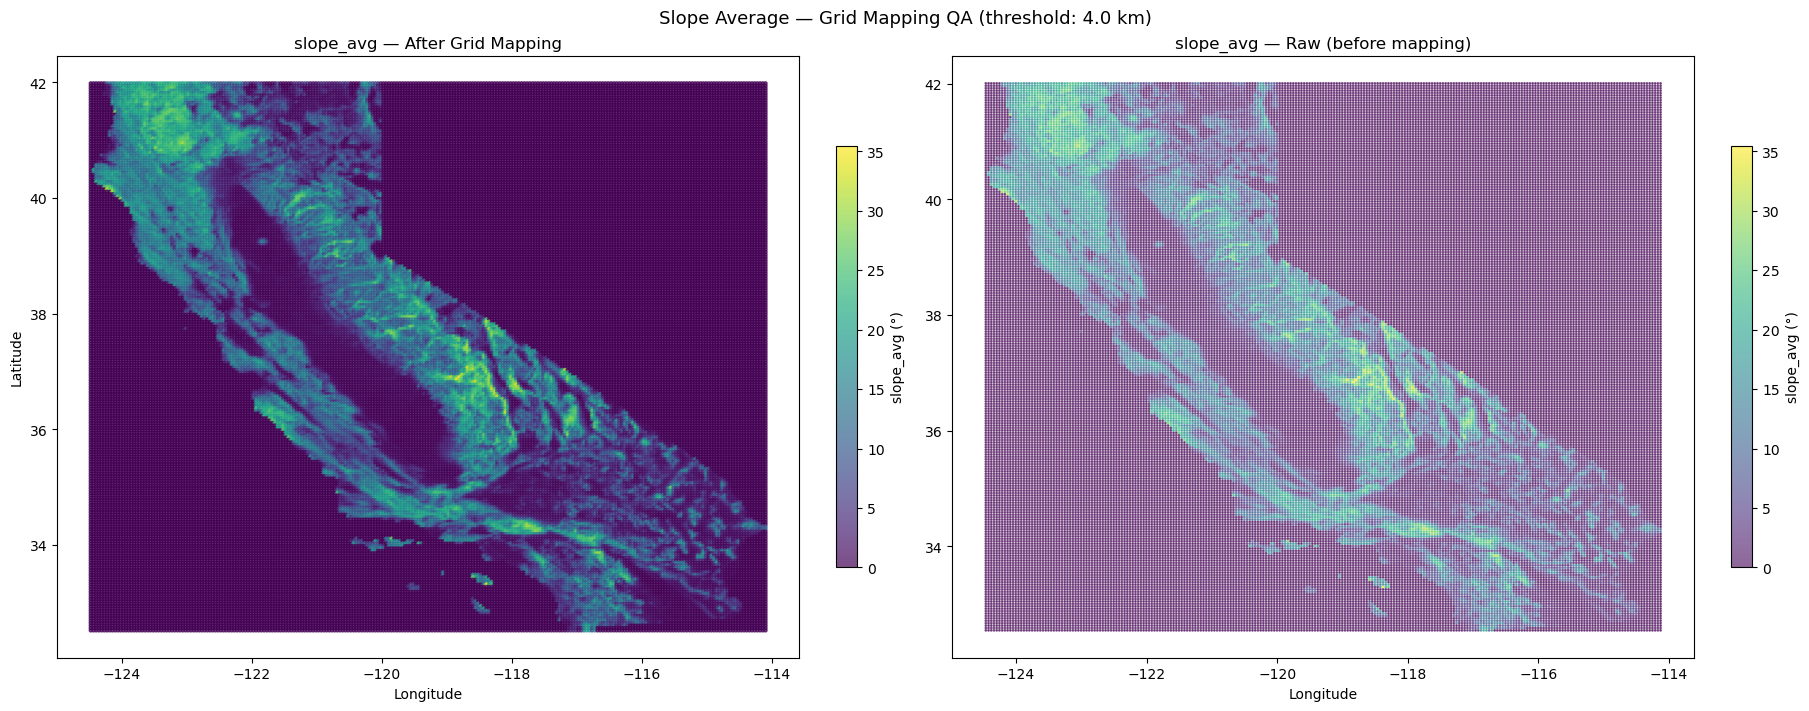

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

matched = reference_grid[reference_grid['distance_km'].notna()]

sc1 = axes[0].scatter(matched['lon'], matched['lat'],
                      c=matched['slope_avg'], cmap='viridis', s=5, alpha=0.7)
axes[0].set_title('slope_avg — After Grid Mapping')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
fig.colorbar(sc1, ax=axes[0], label='slope_avg (°)', shrink=0.7)

sc2 = axes[1].scatter(slope_data['lon'], slope_data['lat'],
                      c=slope_data['slope_avg'], cmap='viridis', s=1, alpha=0.6)
axes[1].set_title('slope_avg — Raw (before mapping)')
axes[1].set_xlabel('Longitude')
fig.colorbar(sc2, ax=axes[1], label='slope_avg (°)', shrink=0.7)

plt.suptitle(f'Slope Average — Grid Mapping QA (threshold: {MAX_MATCH_KM} km)', fontsize=13)
plt.show()

---

# Phase E: Save

Save the matched grid as a Parquet file. The `distance_km` column is dropped
before saving — it was for QA only. This file is consumed by `02_05`
when building the static feature grid.

In [13]:
output = reference_grid[['lon', 'lat', 'slope_avg', 'slope_max']]

# Create output directory if it doesn't exist
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

output.to_parquet(OUTPUT_PATH, index=False)

print(f"Saved -> {OUTPUT_PATH}")
print(f"File size  : {os.path.getsize(OUTPUT_PATH)/1e6:.1f} MB")
print(f"Final shape: {output.shape[0]:,} rows × {output.shape[1]} cols")
print(f"Columns    : {list(output.columns)}")

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Slope_Data\lon_lat_pair_weather_match_slope.parquet
File size  : 0.2 MB
Final shape: 62,160 rows × 4 cols
Columns    : ['lon', 'lat', 'slope_avg', 'slope_max']


## 10. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Load | `slope_avg.nc` + `slope_max.nc` | Two slope variables |
| A | Fill NA | NaN → 0 before merging | Flat/ocean areas = 0 |
| A | Merge | Inner join on (lon, lat) | Single slope DataFrame |
| A | Visualize | Scatter plots of raw slope | Coverage confirmed |
| B | Weather grid | Extract lon/lat Cartesian grid from NetCDF | Reference grid |
| C | KD-Tree | Approximate nearest neighbour | Fast initial match |
| C | Geodesic | Exact km distances | QA — identify ocean cells |
| D | Mask | Distance > 4.0 km → 0 | Ocean / boundary cells zeroed |
| D | Visualize | Before vs. after grid mapping | Spatial pattern preserved |
| E | Save | `lon_lat_pair_weather_match_slope.parquet` | Input for `02_05` |